In [5]:
# import stuff
import asymmetree.treeevolve as te
import networkx as nx
import matplotlib.pyplot as plt
import random
import numpy as np
import MISC_Functions
import copy

from asymmetree.visualization.tree_vis import visualize, assign_colors
from collections import defaultdict
from networkx.drawing.nx_pydot import graphviz_layout
from bmg_Tony import bmg, bmg_fast
from MISC_Functions import biccherry, MultiLayerdBICCherry
from bmg_fun import convert_to_nx
from insert_hybrid import insertHybrid, insertHybrid2
from BICcherryRestrict import BICcherryRestrict
from asymmetree.analysis import bmg_from_tree, is_bmg


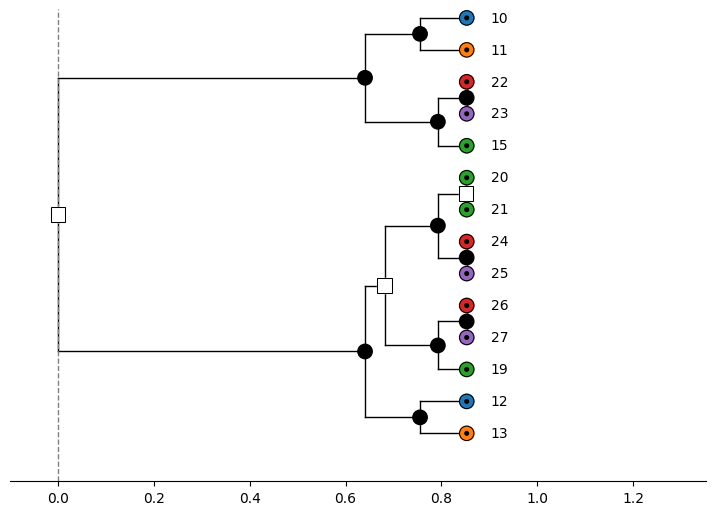

In [6]:
speciesTree, geneTree = MISC_Functions.generateTree(seed = 1,nSpecies = 5)
# Gute Kombinationen:
# (43,2), (1,5)
# get color dicts
species_colors, gene_colors = assign_colors(speciesTree, geneTree)
# visualize asymetree tree
visualize(geneTree, color_dict=gene_colors)

# convert to networkx
Tree = convert_to_nx(geneTree)

# Original BMG:
BMG = bmg(Tree)
BC = BICcherryRestrict(BMG)
BMGBC = bmg(BC)

if not nx.utils.graphs_equal(BMG, BMGBC):
    print("the BMG already breaks for the Tree")

In [7]:
"""
Konsolidierter Code fuer die Untersuchung, wann ein einzelner eingefuegter
Hybrid im Netzwerk dazu fuehrt, dass BMG(Network) != BMG(BICcherryRestrict(BMG)).

Enthaelt:
  - check_hybrid_criteria(...): Kriterien-Pruefung (Suche nach BMG Chains)
  - der Haupt-Loop mit Ereignis-Sammlung (events, anomalies, false_positives)
  - Plot-Funktionen fuer Netzwerk + BMG nebeneinander

Voraussetzung: Tree, bmg(...), BICcherryRestrict(...), insertHybrid2(...)
sind bereits an anderer Stelle im Notebook definiert.
"""

# =====================================================================
# 1. Kriterien-Pruefung
# =====================================================================


def check_criteria(BMG: nx.DiGraph):
    """
    Prueft, ob BMG mindestens eine "Kette" fehlender/asymmetrischer Best
    Matches enthaelt, die der (einstufige) BIC-Cherry-Expansion-Algorithmus
    (BCEA) -- mit reziprozitaets-bevorzugter Kandidatenwahl -- unter der
    weak-Definition nicht korrekt darstellen kann.
 
    Formale Kriterium
    ------------------
    Mit N(x) = {y : (x,y) in E(BMG)} (echte Best Matches von x) und
    L_c = {v in V : sigma(v) = c} (alle Gene der Farbe c):
 
    BMG ist NICHT durch den (einstufigen) BCEA darstellbar genau dann, wenn
 
        exists x in V, exists Farbe c != sigma(x):
            N(x) ∩ L_c  ⊊  L_c                     (x deckt c nicht vollstaendig ab)
            und  fuer alle z in N(x) ∩ L_c:  (z,x) not in E    (KEIN Kandidat reziprok)
 
    Kurz: x braucht eine Korrektur bzgl. Farbe c (mind. ein Gen dieser
    Farbe fehlt x als Match), UND unter x's tatsaechlichen Matches dieser
    Farbe ist KEIN EINZIGER reziprok. Weil die Kandidatenwahl im BCEA
    reziproke Kandidaten bevorzugt (siehe insertNode/findCandidate), reicht
    schon EIN reziproker Kandidat aus, um den Bruch zu vermeiden -- daher
    "fuer alle" statt (wie in einer frueheren Version) "es existiert einer".
 
    Deckt x eine Farbe schon vollstaendig ab, bleibt die urspruengliche
    P-Cherry ohnehin unangetastet -- daher zaehlt das nicht als Bruchgrund,
    selbst wenn dort asymmetrische Matches vorkommen.
 
    Parameters
    ----------
    BMG : networkx.DiGraph
        Das zu pruefende (Ziel-)BMG. Jeder Knoten braucht ein "color"-Attribut.
 
    Returns
    -------
    has_chain : bool
        True, wenn mindestens eine Kette gefunden wurde.
    chains : list[dict]
        Alle gefundenen Ketten, je mit den Schluesseln "x", "color",
        "candidates" (ALLE tatsaechlichen Matches von x dieser Farbe --
        jeder davon ist nicht-reziprok, sonst waere keine Kette gemeldet),
        "missing_example" (ein Beispiel-y der Farbe, das x fehlt).
    """
    nodes_by_color: dict = {}
    for n, data in BMG.nodes(data=True):
        nodes_by_color.setdefault(data["color"], set()).add(n)
 
    chains = []
 
    for x in BMG.nodes():
        color_x = BMG.nodes[x]["color"]
        successors_x = set(BMG.successors(x))
 
        for c, members in nodes_by_color.items():
            if c == color_x:
                continue
 
            matched = successors_x & members
            missing = members - matched
            if not missing:
                continue  # x deckt Farbe c vollstaendig ab -> keine Korrektur noetig
 
            reciprocal = [z for z in matched if BMG.has_edge(z, x)]
            if reciprocal:
                continue  # BCEA waehlt bevorzugt einen reziproken Kandidaten -> kein Bruch erwartet
 
            # alle Kandidaten dieser Farbe sind nicht-reziprok -> Bruch erwartet
            chains.append({
                "x": x, "color": c,
                "candidates": sorted(matched, key=str),
                "missing_example": next(iter(missing)),
            })
 
    return len(chains) > 0, chains




# =====================================================================
# 3. Haupt-Loop mit Ereignis-Sammlung
# =====================================================================

def run_experiment(Tree, runs: int = 100, mode: str = "weak", max_hybrids: int = 100, seed: int = 0):
    """
    Fuehrt `runs` unabhaengige Simulationen durch. In jeder wird
    schrittweise ein Hybrid nach dem anderen in eine Kopie von `Tree`
    eingefuegt, bis entweder BMG(Network) != BMG(BICcherryRestrict(BMG))
    ("broke") oder `max_hybrids` erreicht ist ("zensiert").

    Zusaetzlich wird pro Hybrid-Insertion die Hypothese "asymmetrische
    Blatt-Cherry => Bruch" strukturell an BC getestet (predicted_break),
    unabhaengig von der tatsaechlichen Bruch-Erkennung ueber graphs_equal.

    Returns
    -------
    events : list[dict]
        Ein Eintrag PRO Hybrid-Insertion (ueber alle Runs).
    anomalies : list[dict]
        False negatives der ALTEN globalen Kriteriums-Pruefung: broke=True,
        aber matched=False (siehe check_hybrid_criteria).
    false_positives : list[dict]
        matched=True, aber broke=False (alte Kriteriums-Pruefung).
    hypothesis_mismatches : list[dict]
        Faelle, in denen predicted_break != broke -- das ist der direkte
        Test eurer neuen Cherry-Hypothese. Idealerweise leer.
    hybrids_before_break : list[int]
        Anzahl Hybriden bis zum Bruch, NUR fuer Runs mit echtem Bruch
        (zensierte Runs, die das Limit erreicht haben, sind ausgeschlossen).
    """
    random.seed(seed)

    events = []
    anomalies = []
    false_positives = []
    hypothesis_mismatches = []
    hybrids_before_break = []

    for i in range(runs):
        Network = copy.deepcopy(Tree)
        BMG = bmg(Tree, mode=mode)
        BC = BICcherryRestrict(BMG)
        BMGBC = bmg(BC, mode=mode)

        count = 0
        broke = False
        node1 = node2 = None

        while nx.utils.graphs_equal(BMG, BMGBC) and count < max_hybrids:
            Network, combinedNodes = insertHybrid2(Network)
            node1, node2 = combinedNodes
            BMG = bmg(Network, mode=mode)
            BC = BICcherryRestrict(BMG)
            BMGBC = bmg(BC, mode=mode)
            count += 1

            broke = not nx.utils.graphs_equal(BMG, BMGBC)
            predicted_break, chains = check_criteria(BMG)


            events.append({
                "run": i, "hybrid_index": count,
                "broke": broke,
                "chains": chains,
                "predicted_break": predicted_break,
            })

            if broke and not predicted_break:
                anomalies.append({
                    "run": i, "hybrid_index": count,
                    "network": copy.deepcopy(Network),
                    "node1": node1, "node2": node2,
                    "missing": set(BMG.edges()) - set(BMGBC.edges()),
                    "extra": set(BMGBC.edges()) - set(BMG.edges()),
                })

            if predicted_break and not broke:
                false_positives.append({
                    "run": i, "hybrid_index": count,
                    "label": chains,
                    "network": copy.deepcopy(Network),
                    "node1": node1, "node2": node2,
                })

            if predicted_break != broke:
                hypothesis_mismatches.append({
                    "run": i, "hybrid_index": count,
                    "predicted_break": predicted_break, "broke": broke,
                    "network": copy.deepcopy(Network), "BC": copy.deepcopy(BC),
                    "node1": node1, "node2": node2,
                })

        if broke:
            hybrids_before_break.append(count)
        # sonst: Run hat das Limit erreicht, ohne zu brechen -> zensiert, nicht mitzaehlen

    return events, anomalies, false_positives, hypothesis_mismatches, hybrids_before_break


def print_summary(events, hybrids_before_break, runs):
    tp = sum(e["broke"] and e["predicted_break"] for e in events)
    fn = sum(e["broke"] and not e["predicted_break"] for e in events)
    fp = sum((not e["broke"]) and e["predicted_break"] for e in events)
    tn = sum((not e["broke"]) and not e["predicted_break"] for e in events)

    print("=== Hypothese: asymmetrische Blatt-Cherry in BC => Break ===")
    print(f"TP (Hypothese sagt Break richtig vorher): {tp}")
    print(f"FN (Break, aber KEINE best match chain gefunden): {fn}   <- widerlegt die Hypothese, falls > 0")
    print(f"FP (best match chain gefunden, aber kein break):  {fp}   <- widerlegt die Hypothese, falls > 0")
    print(f"TN (weder noch):                                {tn}")
    if tp + fn:
        print(f"Recall:    {tp/(tp+fn):.2%}")
    if tp + fp:
        print(f"Precision: {tp/(tp+fp):.2%}")
    if fn == 0 and fp == 0:
        print(">>> Hypothese trifft auf ALLE Ereignisse exakt zu (100% Recall & Precision).")
    print(f"\nEchte (nicht zensierte) Breaks: {len(hybrids_before_break)} / {runs}")
    if hybrids_before_break:
        print(f"Oe Hybriden bis Break:          {np.mean(hybrids_before_break):.2f}")


# =====================================================================
# 4. Plot-Funktionen
# =====================================================================

def get_color_map(*graphs):
    """Erzeugt eine konsistente Farbzuordnung fuer beliebige color-Attributwerte.
    Sortiert nach str(), damit gemischte Typen (z.B. int-Blattfarben und
    tuple-Hybridfarben) den Vergleich nicht zum Absturz bringen."""
    all_colors = set()
    for g in graphs:
        all_colors |= {data["color"] for _, data in g.nodes(data=True) if "color" in data}
    palette = plt.cm.tab10.colors
    return {c: palette[i % len(palette)] for i, c in enumerate(sorted(all_colors, key=str))}


def node_display_color(G: nx.DiGraph, n, color_map):
    """Blaetter bekommen ihre echte Speziesfarbe; interne/Hybrid-Knoten
    (die evtl. gar keine sinnvolle color haben, z.B. gemischte Tupel)
    werden neutral grau dargestellt."""
    if G.out_degree(n) == 0 and "color" in G.nodes[n]:
        return color_map[G.nodes[n]["color"]]
    return (0.8, 0.8, 0.8)


def layered_layout(G: nx.DiGraph):
    """Einfaches Ebenen-Layout fuer DAGs (Wurzel oben, Blaetter unten)."""
    pos = {}
    for depth, generation in enumerate(nx.topological_generations(G)):
        gen = list(generation)
        for j, node in enumerate(gen):
            pos[node] = (j - len(gen) / 2, -depth)
    return pos


def plot_network_and_bmg(Network: nx.DiGraph, BMG: nx.DiGraph, title: str = ""):
    color_map = get_color_map(Network, BMG)
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # --- Netzwerk (Ebenen-Layout, da DAG) ---
    pos_net = layered_layout(Network)
    node_colors_net = [node_display_color(Network, n, color_map) for n in Network.nodes()]
    nx.draw(
        Network, pos_net, ax=axes[0], with_labels=True,
        node_color=node_colors_net, node_size=600,
        font_size=8, arrows=True, arrowsize=12,
    )
    axes[0].set_title("Netzwerk")

    # --- BMG (kann Kanten in beide Richtungen haben -> spring_layout) ---
    pos_bmg = nx.spring_layout(BMG, seed=0)
    node_colors_bmg = [node_display_color(BMG, n, color_map) for n in BMG.nodes()]
    nx.draw(
        BMG, pos_bmg, ax=axes[1], with_labels=True,
        node_color=node_colors_bmg, node_size=600,
        font_size=8, arrows=True, arrowsize=12,
        connectionstyle="arc3,rad=0.15",  # trennt Hin-/Rueckkante optisch
    )
    axes[1].set_title("BMG")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_anomalies(anomalies, mode: str = "weak", limit=None):
    """Zeichnet Netzwerk + BMG fuer jede Anomalie (broke, aber Kriterium matcht nicht)."""
    for a in anomalies[:limit]:
        plot_network_and_bmg(
            a["network"],
            bmg(a["network"], mode=mode),
            title=(
                f"ANOMALIE - Run {a['run']}, Hybrid #{a['hybrid_index']}  |  "
                f"node1={a['node1']}, node2={a['node2']}\n"
                f"missing={a['missing']}  extra={a['extra']}"
            ),
        )


def plot_false_positives(false_positives, mode: str = "weak", limit=None):
    """Zeichnet Netzwerk + BMG fuer jeden False Positive (Kriterium matcht, aber kein Break)."""
    for fp in false_positives[:limit]:
        plot_network_and_bmg(
            fp["network"],
            bmg(fp["network"], mode=mode),
            title=(
                f"FALSE POSITIVE ({fp['label']}) - Run {fp['run']}, Hybrid #{fp['hybrid_index']}  |  "
                f"node1={fp['node1']}, node2={fp['node2']}"
            ),
        )


def plot_hypothesis_mismatches(hypothesis_mismatches, mode: str = "weak", limit=None):
    """Zeichnet Netzwerk + BC fuer jeden Fall, in dem die Cherry-Hypothese
    (asymmetrische Blatt-Cherry in BC <=> Break) NICHT zutraf."""
    for m in hypothesis_mismatches[:limit]:
        plot_network_and_bmg(
            m["BC"],
            bmg(m["network"], mode=mode),
            title=(
                f"HYPOTHESE-MISMATCH - Run {m['run']}, Hybrid #{m['hybrid_index']}  |  "
                f"predicted_break={m['predicted_break']}, broke={m['broke']}\n"
            ),
        )


# =====================================================================
# 5. Ausfuehrung
# =====================================================================

if __name__ == "__main__":
    RUNS = 1000
    MODE = "weak"

    events, anomalies, false_positives, hypothesis_mismatches, hybrids_before_break = run_experiment(
        Tree, runs=RUNS, mode=MODE, max_hybrids=100, seed=2
    )
    print_summary(events, hybrids_before_break, RUNS)

    # Beispiele anschauen (limit=None fuer alle):
    plot_false_positives(false_positives,mode = MODE, limit = 5)
    plot_hypothesis_mismatches(hypothesis_mismatches, mode=MODE, limit=5)
    plot_anomalies(anomalies, mode = MODE, limit = 5)
    


=== Hypothese: asymmetrische Blatt-Cherry in BC => Break ===
TP (Hypothese sagt Break richtig vorher): 1000
FN (Break, aber KEINE best match chain gefunden): 0   <- widerlegt die Hypothese, falls > 0
FP (best match chain gefunden, aber kein break):  0   <- widerlegt die Hypothese, falls > 0
TN (weder noch):                                798
Recall:    100.00%
Precision: 100.00%
>>> Hypothese trifft auf ALLE Ereignisse exakt zu (100% Recall & Precision).

Echte (nicht zensierte) Breaks: 1000 / 1000
Oe Hybriden bis Break:          1.80


the BMG already breaks for the Tree


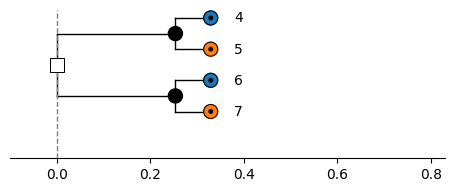

In [11]:
### Tree Generation

speciesTree, geneTree = MISC_Functions.generateTree(seed =43, nSpecies = 2)
# Gute Kombinationen:
# (43,2), (1,5)
# get color dicts
species_colors, gene_colors = assign_colors(speciesTree, geneTree)
# visualize asymetree tree

if not nx.utils.graphs_equal(BMG, BMGBC):
    print("the BMG already breaks for the Tree")


visualize(geneTree, color_dict=gene_colors)

# convert to networkx
Tree = convert_to_nx(geneTree)

# Original BMG:
BMG = bmg(Tree,mode='weak')
BC = BICcherryRestrict(BMG)
BMGBC = bmg(BC,mode='weak')

Es konnten 7 Hybride eingefügt werden, bevor die BMGs nicht mehr übereinstimmten
set()


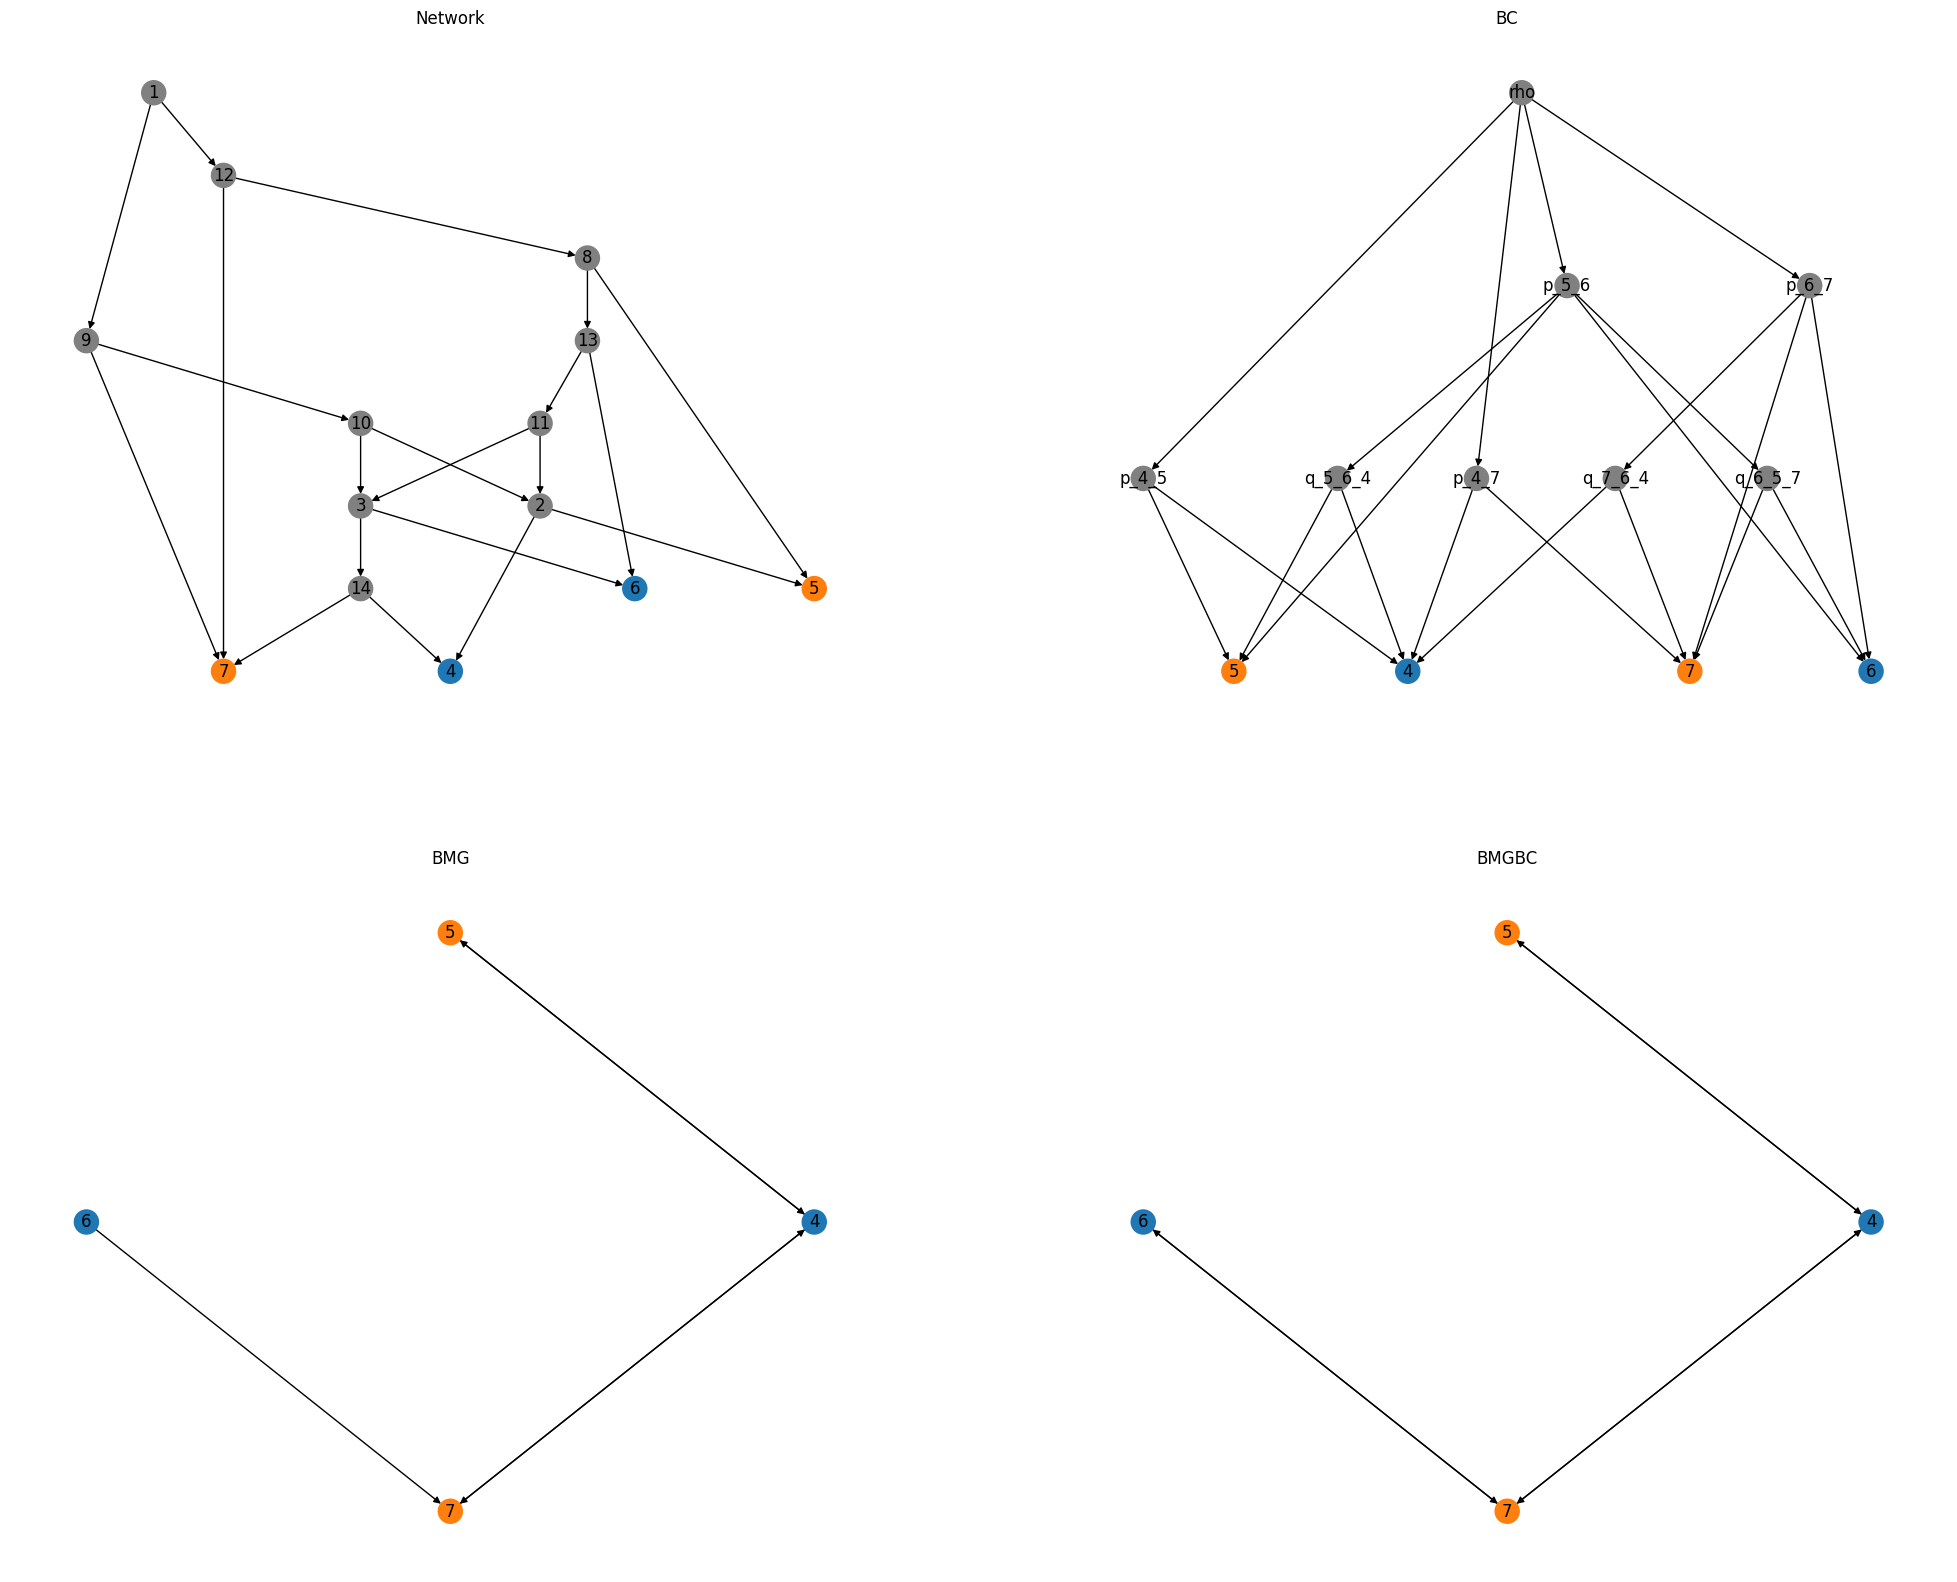

In [24]:
# Testen, wie viele Hybride man einfügen kann, bevor die beiden BMGs nicht mehr übereinstimmen
# random.seed(6)
mode = "weak"
count = 0
Network = copy.deepcopy(Tree)
BMG = bmg(Tree)
# BC = MultiLayerdBICCherry(BMG)
BC = BICcherryRestrict(BMG)
BMGBC = bmg(BC)

while nx.utils.graphs_equal(BMG, BMGBC) and count < 100:
    Network,combinedNodes = insertHybrid2(Network)
    BMG = bmg(Network, mode = mode)
    # BC = MultiLayerdBICCherry(BMG)
    BC = BICcherryRestrict(BMG)
    BMGBC = bmg(BC, mode = mode)
    count += 1
    # if count % 10 == 0:
    #     print("Count = ",count)

    # prüfen, ob der zuletzt generierte Hybrid 2 leaves unterschiedlicher Farbe sind
    # node1 = combinedNodes[0]
    # node2 = combinedNodes[1]

    # if Network.nodes[node1]['color']!=Network.nodes[node2]['color']:
    #     print("Durch den Hybrid wurden zwei Äste unterschiedlicher Farbe direkt verbunden")

    # if Network.nodes[node1]['color']!=Network.nodes[node2]['color'] and Network.out_degree(node1) == 0 and Network.out_degree(node2) == 0:
    #     print("Durch den Hybrid wurden zwei Blätter unterschiedlicher Farbe direkt verbunden")

print("Es konnten",count,"Hybride eingefügt werden, bevor die BMGs nicht mehr übereinstimmten")


# gene color dict turn keys to strings
gene_colors_str = {str(k): v for k, v in gene_colors.items()}

# visualize tree and network
fig, axes = plt.subplots(2, 2, figsize=(25, 20))

pos = graphviz_layout(Network, prog="dot")
nodes_list = [v for v in Network.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]

nx.draw(Network, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True, ax=axes[0,0])
axes[0,0].set_title("Network")

pos = graphviz_layout(BC, prog="dot")
nodes_list = [v for v in BC.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
nx.draw(BC, pos, nodelist=nodes_list, node_color= nodes_colors, with_labels = True, ax=axes[0,1])
axes[0,1].set_title("BC")


nodes_list = [v for v in BMG.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
axes[1,0].set_title("BMG")
nx.draw(BMG, nx.circular_layout(BMG), nodelist=nodes_list, node_color= nodes_colors, ax=axes[1,0], with_labels=True)


nodes_list = [v for v in BMGBC.nodes()]
nodes_colors = [gene_colors_str.get(v, "grey") for v in nodes_list]
axes[1,1].set_title("BMGBC")
nx.draw(BMGBC, nx.circular_layout(BMG), nodelist=nodes_list, node_color= nodes_colors, ax=axes[1,1], with_labels=True)

print(BMG.edges - BMGBC.edges)
